In [3]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model

def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(6, 6, 6), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved

class AffineNet(object):
    def __init__(self, input_shape=(128, 128, 64), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        d, h, w = input_shape
        input_shape = input_shape + (in_channels,)
        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        
        
        x_in = layers.concatenate([static, moving], axis=-1)

        # encoder
        x1 = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x_in)
        x1 = layers.LeakyReLU(alpha=0.2)(x1)  # 16
        x1 = layers.BatchNormalization()(x1)      

        x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x1)
        x2 = layers.LeakyReLU(alpha=0.2)(x2)  # 8
        x2 = layers.BatchNormalization()(x2)      

        x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x2)
        x3 = layers.LeakyReLU(alpha=0.2)(x3)  # 4
        x3 = layers.BatchNormalization()(x3)      

        x4 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                            kernel_initializer='he_normal')(x3)
        x4 = layers.LeakyReLU(alpha=0.2)(x4)  # 2 # 4 for 64
        x4 = layers.BatchNormalization()(x4)      

        s = 1.0  # scaling
        t = 0  # translation
        x = layers.Flatten()(x4)
        x = layers.Dense(64, activation='relu')(x)  # 4*4*32
        x = layers.Dense(12, kernel_initializer='zeros',
                         bias_initializer=tf.constant_initializer([s,0,0,t,0,s,0,t,0,0,s,t]), name='theta')(x)
        
        
        nb, _ = tf.shape(x)
        self.theta = tf.reshape(x, [nb, 3, 4])
        grid = regular_grid_3d(d, h, w)
        grid_new = grid_transform_3d(self.theta, grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)

        moved = grid_sample_3d(moving, grid_new, name='moved')

        model = tf.keras.Model(inputs={'moving': moving, 'static': static},
                                outputs={'moved': moved}, name='AffineNet')
        
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model
        
#     def theta_get(self):
#         return model.get_layer('theta')

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)
    
    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)
    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
    
        
#     def get_theta(self):
#         return self.theta
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [4]:
def grid_transform_3d(theta, grid):
    nb = tf.shape(theta)[0]
    nd, nh, nw, _ = tf.shape(grid)

    i = grid[..., 0] # d, h, w
    j = grid[..., 1]
    k = grid[..., 2]

    i_flat = tf.reshape(i, shape=[-1])
    j_flat = tf.reshape(j, shape=[-1])
    k_flat = tf.reshape(k, shape=[-1])

    ones = tf.ones_like(i_flat)

    grid_flat = tf.stack([i_flat, j_flat, k_flat, ones])
    grid_flat = tf.expand_dims(grid_flat, axis=0)
    grid_flat = tf.tile(grid_flat, tf.stack([nb, 1, 1]))  # n, 4, d*h*w

    # 2d 2x3; 3d 3x4
    theta = tf.cast(theta, 'float32')
    grid_flat = tf.cast(grid_flat, 'float32')
    grid_new = tf.matmul(theta, grid_flat)  # n, 3, d*h*w
    
    grid_new = tf.transpose(grid_new, perm=[0,2,1])
    grid_new = tf.reshape(grid_new, [nb, nd, nh, nw, 3])

    return grid_new

In [5]:
batch_size = 4
epochs = 500
lr = 0.001  # learning rate
lamda = 0.2  # (lambda) regularization parameter
input_shape = (64, 128, 128)

In [4]:
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./chaos_train_voxel/exis_mixed.nii.gz"
filename2 = "./chaos_train_voxel/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

0.0
16658.0


In [64]:
# print(data[0].shape)

# a = data[0]
# print(a.shape)
# a = a.swapaxes(0,2) 

# print(a.shape)
# a = nib.Nifti1Image(a,None) 

# nib.save(a,'./chaos_train_voxel/test.nii.gz')

In [5]:
x_train = data[:13, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[13:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)

train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=True)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=True)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

Train:  (13, 64, 128, 128, 1)
Test:  (6, 64, 128, 128, 1)
Sample:  (19, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)


In [6]:
ncc_loss = global_normalized_cross_correlation_loss()
grad_loss = gradient_loss()

# Map model outputs to the loss functions and loss weights
loss_weights = {'moved': 1.0}
losses = {'moved': ncc_loss}

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = AffineNet(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [8]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=250, restore_best_weights=True) 
checkpoint_path = "./Affinecheck/0627_cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

Epoch 1/500
4/4 [==============================] - ETA: 0s - loss: -0.5739
Epoch 00001: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 330ms/step - loss: -0.5739 - val_loss: -0.6174
Epoch 2/500
4/4 [==============================] - ETA: 0s - loss: -0.6347
Epoch 00002: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 253ms/step - loss: -0.6347 - val_loss: -0.6250
Epoch 3/500
4/4 [==============================] - ETA: 0s - loss: -0.6398
Epoch 00003: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 324ms/step - loss: -0.6398 - val_loss: -0.6274
Epoch 4/500
4/4 [==============================] - ETA: 0s - loss: -0.6420
Epoch 00004: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 262ms/step - loss: -0.6420 - val_loss: -0.6314
Epoch 5/500
4/4 [==============================] - ETA: 0s - loss: -0.6869
Epoch 00005: saving model to ./Affinecheck/06

4/4 [==============================] - ETA: 0s - loss: -0.7803
Epoch 00075: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 256ms/step - loss: -0.7803 - val_loss: -0.7123
Epoch 76/500
4/4 [==============================] - ETA: 0s - loss: -0.7798
Epoch 00076: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 257ms/step - loss: -0.7798 - val_loss: -0.7181
Epoch 77/500
4/4 [==============================] - ETA: 0s - loss: -0.7814
Epoch 00077: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 259ms/step - loss: -0.7814 - val_loss: -0.7136
Epoch 78/500
4/4 [==============================] - ETA: 0s - loss: -0.7775
Epoch 00078: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 324ms/step - loss: -0.7775 - val_loss: -0.7282
Epoch 79/500
4/4 [==============================] - ETA: 0s - loss: -0.7807
Epoch 00079: saving model to ./Affinecheck/0627_cp.ck

Epoch 149/500
4/4 [==============================] - ETA: 0s - loss: -0.7873
Epoch 00149: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 249ms/step - loss: -0.7873 - val_loss: -0.7735
Epoch 150/500
4/4 [==============================] - ETA: 0s - loss: -0.7833
Epoch 00150: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 325ms/step - loss: -0.7833 - val_loss: -0.7633
Epoch 151/500
4/4 [==============================] - ETA: 0s - loss: -0.7748
Epoch 00151: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 315ms/step - loss: -0.7748 - val_loss: -0.7729
Epoch 152/500
4/4 [==============================] - ETA: 0s - loss: -0.7747
Epoch 00152: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 254ms/step - loss: -0.7747 - val_loss: -0.7600
Epoch 153/500
3/4 [=====================>........] - ETA: 0s - loss: -0.7851
Epoch 00153: saving model to ./Affi

Epoch 186/500
4/4 [==============================] - ETA: 0s - loss: -0.7947
Epoch 00186: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 253ms/step - loss: -0.7947 - val_loss: -0.7819
Epoch 187/500
3/4 [=====================>........] - ETA: 0s - loss: -0.7945
Epoch 00187: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 253ms/step - loss: -0.7955 - val_loss: -0.7810
Epoch 188/500
4/4 [==============================] - ETA: 0s - loss: -0.7961
Epoch 00188: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 253ms/step - loss: -0.7961 - val_loss: -0.7780
Epoch 189/500
4/4 [==============================] - ETA: 0s - loss: -0.7946
Epoch 00189: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 317ms/step - loss: -0.7946 - val_loss: -0.7781
Epoch 190/500
4/4 [==============================] - ETA: 0s - loss: -0.7957
Epoch 00190: saving model to ./Affi

Epoch 223/500
4/4 [==============================] - ETA: 0s - loss: -0.7936
Epoch 00223: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 264ms/step - loss: -0.7936 - val_loss: -0.7852
Epoch 224/500
4/4 [==============================] - ETA: 0s - loss: -0.7854
Epoch 00224: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 270ms/step - loss: -0.7854 - val_loss: -0.7674
Epoch 225/500
4/4 [==============================] - ETA: 0s - loss: -0.7832
Epoch 00225: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 254ms/step - loss: -0.7832 - val_loss: -0.7758
Epoch 226/500
4/4 [==============================] - ETA: 0s - loss: -0.7897
Epoch 00226: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 278ms/step - loss: -0.7897 - val_loss: -0.7768
Epoch 227/500
4/4 [==============================] - ETA: 0s - loss: -0.7909
Epoch 00227: saving model to ./Affi

...

Epoch 334/500
3/4 [=====================>........] - ETA: 0s - loss: -0.8003
Epoch 00334: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 258ms/step - loss: -0.7991 - val_loss: -0.7805
Epoch 335/500
4/4 [==============================] - ETA: 0s - loss: -0.7969
Epoch 00335: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 253ms/step - loss: -0.7969 - val_loss: -0.7795
Epoch 336/500
4/4 [==============================] - ETA: 0s - loss: -0.7954
Epoch 00336: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 255ms/step - loss: -0.7954 - val_loss: -0.7695
Epoch 337/500
4/4 [==============================] - ETA: 0s - loss: -0.7950
Epoch 00337: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 294ms/step - loss: -0.7950 - val_loss: -0.7795
Epoch 338/500
4/4 [==============================] - ETA: 0s - loss: -0.7944
Epoch 00338: saving model to ./Affi

Epoch 371/500
4/4 [==============================] - ETA: 0s - loss: -0.7910
Epoch 00371: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 260ms/step - loss: -0.7910 - val_loss: -0.7800
Epoch 372/500
4/4 [==============================] - ETA: 0s - loss: -0.7927
Epoch 00372: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 347ms/step - loss: -0.7927 - val_loss: -0.7763
Epoch 373/500
4/4 [==============================] - ETA: 0s - loss: -0.7925
Epoch 00373: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 267ms/step - loss: -0.7925 - val_loss: -0.7806
Epoch 374/500
4/4 [==============================] - ETA: 0s - loss: -0.7898
Epoch 00374: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 267ms/step - loss: -0.7898 - val_loss: -0.7750
Epoch 375/500
4/4 [==============================] - ETA: 0s - loss: -0.7839
Epoch 00375: saving model to ./Affi

Epoch 408/500
4/4 [==============================] - ETA: 0s - loss: -0.7900
Epoch 00408: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 261ms/step - loss: -0.7900 - val_loss: -0.7744
Epoch 409/500
4/4 [==============================] - ETA: 0s - loss: -0.7934
Epoch 00409: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 255ms/step - loss: -0.7934 - val_loss: -0.7795
Epoch 410/500
4/4 [==============================] - ETA: 0s - loss: -0.7946
Epoch 00410: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 269ms/step - loss: -0.7946 - val_loss: -0.7770
Epoch 411/500
4/4 [==============================] - ETA: 0s - loss: -0.7976
Epoch 00411: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 273ms/step - loss: -0.7976 - val_loss: -0.7826
Epoch 412/500
3/4 [=====================>........] - ETA: 0s - loss: -0.7970
Epoch 00412: saving model to ./Affi

Epoch 445/500
4/4 [==============================] - ETA: 0s - loss: -0.7949
Epoch 00445: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 266ms/step - loss: -0.7949 - val_loss: -0.7746
Epoch 446/500
4/4 [==============================] - ETA: 0s - loss: -0.7960
Epoch 00446: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 265ms/step - loss: -0.7960 - val_loss: -0.7821
Epoch 447/500
4/4 [==============================] - ETA: 0s - loss: -0.7969
Epoch 00447: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 328ms/step - loss: -0.7969 - val_loss: -0.7809
Epoch 448/500
3/4 [=====================>........] - ETA: 0s - loss: -0.7994
Epoch 00448: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 309ms/step - loss: -0.7981 - val_loss: -0.7846
Epoch 449/500
3/4 [=====================>........] - ETA: 0s - loss: -0.7981
Epoch 00449: saving model to ./Affi

Epoch 482/500
4/4 [==============================] - ETA: 0s - loss: -0.7858
Epoch 00482: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 262ms/step - loss: -0.7858 - val_loss: -0.7714
Epoch 483/500
3/4 [=====================>........] - ETA: 0s - loss: -0.7938
Epoch 00483: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 255ms/step - loss: -0.7930 - val_loss: -0.7802
Epoch 484/500
4/4 [==============================] - ETA: 0s - loss: -0.7918
Epoch 00484: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 261ms/step - loss: -0.7918 - val_loss: -0.7762
Epoch 485/500
4/4 [==============================] - ETA: 0s - loss: -0.7919
Epoch 00485: saving model to ./Affinecheck/0627_cp.ckpt
4/4 [==============================] - 1s 269ms/step - loss: -0.7919 - val_loss: -0.7711
Epoch 486/500
4/4 [==============================] - ETA: 0s - loss: -0.7908
Epoch 00486: saving model to ./Affi

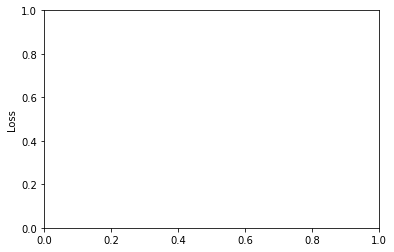

In [68]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

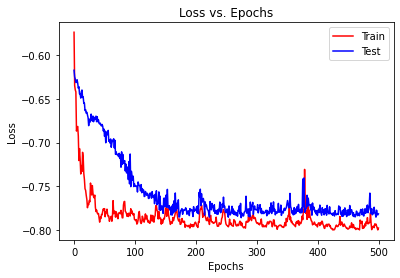

In [69]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()
# plt.savefig('loss_plot.png')hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])


In [70]:
model.save_weights(checkpoint_path)

In [9]:
checkpoint_path = "./Affinecheck/0627_cp.ckpt"
model.load_weights(checkpoint_path)

In [28]:
output = model.predict(sample_loader)

In [34]:
print(max_value)

16658.008


In [35]:
min_value = np.min(moved)
max_value = np.max(moved)
print(min_value)
print(max_value)

0.0
2360.4382


In [33]:
# Voxel Affine 저장 ###########
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * max_value
a = 1
j = 0


In [11]:
f1model = Model(inputs=model.model.input, outputs=model.model.get_layer('theta').output)
theta_x = f1model.predict(sample_loader)

print(theta_x.shape)


(19, 12)


In [12]:
print(theta_x)

[[ 6.34975255e-01  6.90996423e-02  2.22247064e-01  2.87022442e-04
  -3.73449661e-02  1.05694556e+00 -1.21313613e-03 -2.47425586e-01
   1.06256995e-02 -3.17821056e-02  8.66332948e-01 -5.07027246e-02]
 [ 2.16978610e-01  1.02320611e-01  2.02605784e-01  2.73592979e-01
  -1.53930997e-02  8.48896861e-01  1.40758203e-02 -3.38014401e-02
  -3.74129857e-03 -3.03130448e-02  7.78174579e-01 -3.13145332e-02]
 [ 7.23863125e-01  1.12204134e-01  4.85501140e-02  4.38115783e-02
  -2.38934383e-02  1.00402105e+00 -2.54354533e-03 -4.39200588e-02
   2.57611228e-03 -2.10975967e-02  8.64852607e-01 -1.35498019e-02]
 [ 1.94162011e-01  6.86228722e-02  3.27437997e-01  2.16565117e-01
  -2.70204656e-02  9.06317711e-01  1.35507667e-02 -1.98342964e-01
   3.33475112e-03 -3.80167961e-02  7.87679911e-01 -5.94725050e-02]
 [ 2.77442098e-01  9.14815888e-02  2.26838946e-01  2.21834913e-01
  -2.07476132e-02  8.90676975e-01  1.16332555e-02 -9.46403146e-02
  -3.27586895e-04 -3.18480916e-02  7.93359399e-01 -3.90830971e-02]
 [ 9.

In [26]:
# Affine GT 만들기! 파일 불러와서 한번에 다 처리!##########
a = 1
j = 0
for i in range (0, 29):
    filename = "./chaos_train_voxel/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        x = nib.load(filename).get_fdata()
        x = x.astype(np.float32)
        x = x.swapaxes(0,2)
        print(x.shape)
        d,h,w = x.shape
        x = np.expand_dims(x,axis=0)
        x = np.expand_dims(x,axis=-1)

        grid = regular_grid_3d(d,h,w)
        nb = 1
#         print(theta_x[j][1])
        theta = tf.reshape(theta_x[j], [nb,3,4])

        grid_new = grid_transform_3d(theta[0], grid)
        grid_new = tf.clip_by_value(grid_new, -1, 1)


        moved = grid_sample_3d(x, grid_new)
        
        x = np.squeeze(moved[0]) 
        print(x.shape)
        
        d,h,w = x.shape
        x_copy = x.copy()
        
        for dep in range(0,d):
            for hei in range(0, h):
                for wid in range(0,w):
                    if(x_copy[dep,hei,wid] > 0) :
                        x_copy[dep,hei,wid] = 1
        x_copy = x_copy.swapaxes(0,2)
        print(a, ":", x_copy.shape )
        savename = "./chaos_train_voxel/gtaffine/" + str(a) + ".nii.gz"
        x_copy = nib.Nifti1Image(x_copy, None) 
        nib.save(x_copy,savename)
        
        j += 1
        
    a += 1


(64, 128, 128)
(64, 128, 128)
1 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
2 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
5 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
6 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
8 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
10 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
14 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
16 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
18 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
19 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
21 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
22 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
23 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
24 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
25 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
26 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
27 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
28 : (128, 128, 64)
(64, 128, 128)
(64, 128, 128)
29 : (128, 128, 64)


In [126]:
result = model.evaluate(sample_loader)

1/1 [==============================] - 0s 962us/step - loss: -0.3995


In [66]:
moved = moved * max_value
print(moved.shape)
a = moved[0]

print(a.shape)
a = a.swapaxes(0,2) 

a = nib.Nifti1Image(a,None) 

nib.save(a,'Affine 결과/moved_0622.nii.gz')


(1, 64, 128, 128, 1)
(64, 128, 128, 1)


In [79]:
theta.shape

TensorShape([1, 3, 4])

In [69]:
model.summary()

Model: "AffineNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
concatenate_3 (Concatenate)     (None, 64, 128, 128, 0           static[0][0]                     
                                                                 moving[0][0]                     
__________________________________________________________________________________________________
conv3d_12 (Conv3D)              (None, 32, 64, 64, 1 880         concatenate_3[0][0]      